## Dataset Analysis


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("Movies.csv")
print(df.info)

<bound method DataFrame.info of      show_id     type                                    title  \
0         s1  TV Show                                       3%   
1         s2    Movie                                    07:19   
2         s3    Movie                                    23:59   
3         s4    Movie                                        9   
4         s5    Movie                                       21   
...      ...      ...                                      ...   
7782   s7783    Movie                                     Zozo   
7783   s7784    Movie                                   Zubaan   
7784   s7785    Movie                        Zulu Man in Japan   
7785   s7786  TV Show                    Zumbo's Just Desserts   
7786   s7787    Movie  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS   

               director                                               cast  \
0                   NaN  João Miguel, Bianca Comparato, Michel Gomes, R...   
1     Jorge Michel 

In [5]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.shape[0]

7787

### Q1. Find the percentage of Missing values in each column.

In [8]:
missing_value = df.isna().sum()
total = df.shape[0] # or len(df) can be used
print((missing_value/total)* 100)

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
release_year     0.000000
rating           0.089893
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64


In [9]:
# Total Missing Values in DataFrame
mis_val = df.isna().sum().sum()
print("Total Missing Value in complete df: ",mis_val)

# Percentage of Missing Values (overall)
per_val = (mis_val / df.size )*100
print("Percentage of Missing Values in total: ", per_val)

# print(df.size) - this will give the total values = rows * cols
# print(len(df)) - this will give the no. of rows

print()
# Column-wise Missing Values
missing_val = df.isna().sum()
print("Columns      Missing values")
print(missing_val)
print()
# Column-wise Missing percentage
total = len(df)
percentage = (missing_val/total)*100
print(percentage)

Total Missing Value in complete df:  3631
Percentage of Missing Values in total:  3.885749753863276

Columns      Missing values
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
release_year     0.000000
rating           0.089893
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64


### 2. For Columns, "country"and "rating", Replace the Missing value with Most probable value.

In [10]:
# How to handle missing value?
# 1. Fill it with a global constant
# 2.1 Fill it with attribute mean value / median value - when numerical data
# 2.2 Fill it with attribute mode value / constant value / forward fill/ backward fill - when categorical data
# 3. Fill it with attribute mean value for all the samples belonging to the same class
# 4. most probable value - inference-based such as Bayesian formula or decision tree
# 5. Drop the missing row - useful when missing values are less


In [11]:
rating_map = {
    "G": 0,
    "TV-Y": 7,
    "TV-Y7": 7,
    "PG": 10,
    "TV-PG": 10,
    "PG-13": 13,
    "TV-14": 14,
    "R": 17,
    "NC-17": 18,
    "TV-MA": 18,
    "NR": 0,
    "UR": 0,
    "TV-Y7-FV": 7
}
df["rating_numerical"] = df["rating"].map(rating_map)

In [12]:
# Categorical Data
df['country'] = df['country'].fillna(df['country'].mode()[0]) # replaced with first most frequent
# Numerical Data
df["rating"] = df["rating"].fillna(df["rating_numerical"].mean()) # with mean - fillna only take one argument

In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'rating_numerical'],
      dtype='object')

### 3. For "Date_Added" column, Replace NaN with any date in the "Release year" . if Release Year is also  NaN, then drop the row.

In [14]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce") # if error occurs - put NaT
df["date_added"] = df["date_added"].fillna(pd.to_datetime(df["release_year"], format="%Y", errors='coerce'))
df = df.dropna(subset=["date_added"]) # remove those values  which are NaT (Not a Time)

In [19]:
df.head(4)
# Doubt - date added should be like this or it should be changed in this way
# August 14, 2020" → 2020-08-14

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,rating_numerical,Year_Added,Month_Added,Month_Added_readable
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,18.0,2020,8,August
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,18.0,2016,12,December
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",17.0,2018,12,December
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",13.0,2017,11,November


### 4. From Date_Added, Create new columns 'Year_Added' and'Month _Added'.

In [16]:
df["Year_Added"] = df["date_added"].dt.year
df["Month_Added"] = df["date_added"].dt.month
# df["Date_Added"] = df["date_added"].dt.date

In [17]:
# readable month name 
df["Month_Added_readable"] = df["date_added"].dt.month_name()

In [18]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'rating_numerical', 'Year_Added', 'Month_Added',
       'Month_Added_readable'],
      dtype='object')

### 5. Discretize Rating column into three values only ("Kid", "teen" , "Adult").

In [20]:
# By using function 

def categorize(x):
    if( x <=7):
        return 'kid'
    elif(x <= 14):
        return 'teen'
    else:
        return 'Adult'

df['category'] = df['rating_numerical'].apply(categorize)

In [21]:
# By using pandas
df['category'] = pd.cut(
    df['rating_numerical'], bins=[-1,7,14,100],labels=['kid','teen','Adult']
)

### 6. Plot the number of movies in each rating group by each country.

In [22]:
# in this we are having a lot of countries with their names but problem is that we are having 2 or more individual countries and are combined together..

C:\Users\Asus\AppData\Local\Temp\ipykernel_29432\2881631058.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = filtered.groupby(['country','category'] ).size().unstack(fill_value=0) # to handle missing value


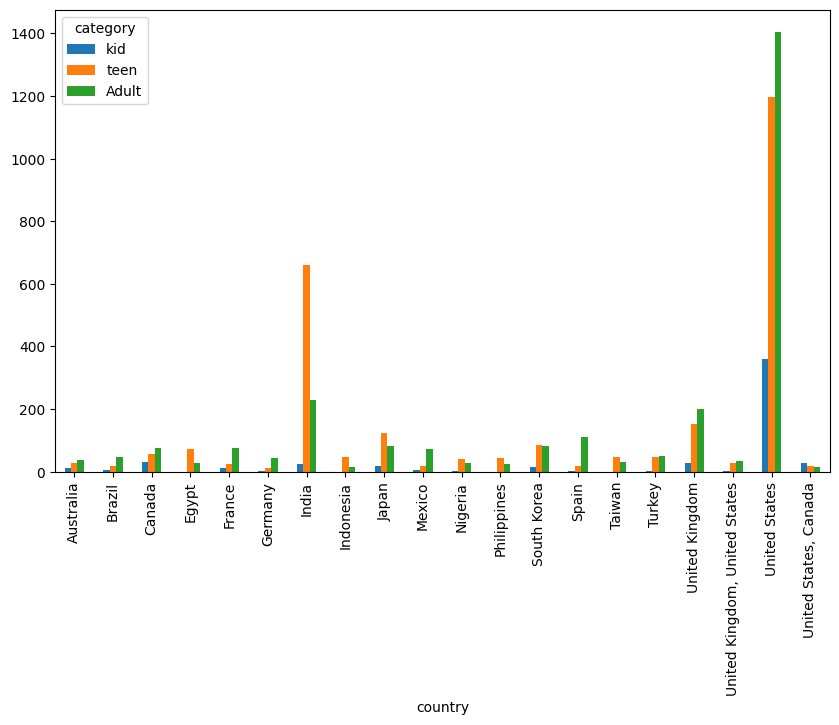

In [23]:
# Doing it for top 20 countries
top_countries = df['country'].value_counts().head(20).index 
# generating only top countries name as array
filtered = df[ df['country'].isin(top_countries) ]
# taking those rows which have top countries
grouped = filtered.groupby(['country','category'] ).size().unstack(fill_value=0) # to handle missing value 
# grouping based on category- kid, teen, adult
grouped.plot(kind ='bar',figsize=(10,6) )
plt.show()

### 7. Change the Listed-In column to single valued column by creating multiple columns foe each unique value in that column.

Need to convert this:

Listed_In

- Drama, Comedy
- Action, Thriller
- Comedy

Into :

| Drama | Comedy | Action | Thriller |
| ----- | ------ | ------ | -------- |
| 1     | 1      | 0      | 0        |
| 0     | 0      | 1      | 1        |
| 0     | 1      | 0      | 0        |


In [24]:
# Easiest way - 
df = df.join(df['listed_in'].str.get_dummies(sep=','))


In [25]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,...,0,0,0,0,0,0,0,0,0,0
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,...,0,0,0,0,0,0,0,0,0,0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,...,0,0,0,0,0,0,0,0,0,0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,...,0,0,0,0,0,0,0,0,0,0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# one such way also  - by finding out the listed_in separated in one array then making it's column and filing values
df_exploded = df.assign(Listed_in = df['listed_in'].str.strip(',')).explode('Listed_in')
df_dummies = pd.get_dummies(df_exploded['Listed_in'])
df = df.join(df_dummies.groupby(level=0)).sum()

### 7.Drop all the columns with large number of distinct values and label encode rest of the columns.

- find out the unique values in each column 
- put a threshold limit if more than that then drop that column
- for categorical data, encode it.

In [26]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'rating_numerical', 'Year_Added', 'Month_Added', 'Month_Added_readable',
       'category', ' Anime Features', ' Children & Family Movies',
       ' Classic & Cult TV', ' Classic Movies', ' Comedies', ' Crime TV Shows',
       ' Cult Movies', ' Documentaries', ' Docuseries', ' Dramas',
       ' Faith & Spirituality', ' Horror Movies', ' Independent Movies',
       ' International Movies', ' International TV Shows', ' Kids' TV',
       ' Korean TV Shows', ' LGBTQ Movies', ' Music & Musicals', ' Reality TV',
       ' Romantic Movies', ' Romantic TV Shows', ' Sci-Fi & Fantasy',
       ' Science & Nature TV', ' Spanish-Language TV Shows', ' Sports Movies',
       ' Stand-Up Comedy', ' Stand-Up Comedy & Talk Shows',
       ' TV Action & Adventure', ' TV Comedies', ' TV Dramas', ' TV Horror',
       ' TV Mysteries', ' TV Sci-Fi & Fant

In [27]:
# finding columns with many unique values
for col in df.columns:
    print(col, df[col].nunique())

show_id 7787
type 2
title 7787
director 4049
cast 6831
country 681
date_added 1517
release_year 73
rating 15
duration 216
listed_in 492
description 7769
rating_numerical 7
Year_Added 15
Month_Added 12
Month_Added_readable 12
category 3
 Anime Features 2
 Children & Family Movies 2
 Classic & Cult TV 2
 Classic Movies 2
 Comedies 2
 Crime TV Shows 2
 Cult Movies 2
 Documentaries 2
 Docuseries 2
 Dramas 2
 Faith & Spirituality 2
 Horror Movies 2
 Independent Movies 2
 International Movies 2
 International TV Shows 2
 Kids' TV 2
 Korean TV Shows 2
 LGBTQ Movies 2
 Music & Musicals 2
 Reality TV 2
 Romantic Movies 2
 Romantic TV Shows 2
 Sci-Fi & Fantasy 2
 Science & Nature TV 2
 Spanish-Language TV Shows 2
 Sports Movies 2
 Stand-Up Comedy 2
 Stand-Up Comedy & Talk Shows 2
 TV Action & Adventure 2
 TV Comedies 2
 TV Dramas 2
 TV Horror 2
 TV Mysteries 2
 TV Sci-Fi & Fantasy 2
 TV Thrillers 2
 Teen TV Shows 2
 Thrillers 2
Action & Adventure 2
Anime Features 2
Anime Series 2
British TV Show

In [58]:
threshold = 50 
high_val_col = []

for cols in df.columns:
    if df[cols].nunique() > threshold:
        high_val_col.append(cols)

low_val_col = []
for cols in df.columns:
    if df[cols].nunique() <= threshold:
        low_val_col.append(cols)

print(high_val_col)
print(low_val_col)

[]
['type', 'rating_numerical', 'Year_Added', 'Month_Added', 'category', ' Anime Features', ' Children & Family Movies', ' Classic & Cult TV', ' Classic Movies', ' Comedies', ' Crime TV Shows', ' Cult Movies', ' Documentaries', ' Docuseries', ' Dramas', ' Faith & Spirituality', ' Horror Movies', ' Independent Movies', ' International Movies', ' International TV Shows', " Kids' TV", ' Korean TV Shows', ' LGBTQ Movies', ' Music & Musicals', ' Reality TV', ' Romantic Movies', ' Romantic TV Shows', ' Sci-Fi & Fantasy', ' Science & Nature TV', ' Spanish-Language TV Shows', ' Sports Movies', ' Stand-Up Comedy', ' Stand-Up Comedy & Talk Shows', ' TV Action & Adventure', ' TV Comedies', ' TV Dramas', ' TV Horror', ' TV Mysteries', ' TV Sci-Fi & Fantasy', ' TV Thrillers', ' Teen TV Shows', ' Thrillers', 'Action & Adventure', 'Anime Features', 'Anime Series', 'British TV Shows', 'Children & Family Movies', 'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows', 'Cult Movies', 'Docum

In [43]:
df.drop(columns= high_val_col, inplace = True)

In [44]:
# should i drop the values by analysing myself that these columns are not needed for ml model training or just rely on the uniqueness
# some what duplicate columns should be deleted or not - like month_added, month_added_readable

In [52]:
df.drop(columns=['rating'] , inplace = True)

In [53]:
df.head()


,type,rating_numerical,Year_Added,Month_Added,category,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
0,1,18.0,2020,8,Adult,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,18.0,2016,12,Adult,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,17.0,2018,12,Adult,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,13.0,2017,11,teen,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,13.0,2020,1,teen,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
# doubt - what will happen if i fill this with unknown value as it is a numerical datatype column
df["rating_numerical"] = df['rating_numerical'].fillna(df['rating_numerical'].ffill())


In [ ]:
m = df.isna().sum()
print(m)
# finding those columns which have any nan value remaining and if so then changing/replacing those values with - mean(), mode(), ffill(), etc..

type                   0
rating                 0
rating_numerical       0
Year_Added             0
Month_Added            0
                      ..
TV Dramas              0
TV Horror              0
TV Sci-Fi & Fantasy    0
TV Shows               0
Thrillers              0
Length: 79, dtype: int64


In [61]:
# Labeling all the data values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in low_val_col:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Doubt -  select.dtype() function how to use it 

In [60]:
df.head()

,type,rating_numerical,Year_Added,Month_Added,category,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
0,1,6,13,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,6,9,11,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,5,11,11,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,3,10,10,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,3,13,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 8. perform correlation analysis on the rest of the labels.

Correlation Analysis - mean - how strongly different numerical columns are related to each other...
- Apply corr() function directly to the df
- if you want to take only numerical data then use select.dtype 

In [ ]:
corr_matrix = df.corr()
print(corr_matrix)

                         type  rating_numerical  Year_Added  Month_Added  \
type                 1.000000         -0.021247    0.005654     0.026568   
rating_numerical    -0.021247          1.000000    0.047321    -0.023705   
Year_Added           0.005654          0.047321    1.000000    -0.121157   
Month_Added          0.026568         -0.023705   -0.121157     1.000000   
category             0.009894         -0.656149   -0.012522     0.035349   
...                       ...               ...         ...          ...   
TV Dramas            0.133816          0.031432   -0.016452     0.006777   
TV Horror            0.053562          0.024028    0.010532     0.020184   
TV Sci-Fi & Fantasy  0.016928         -0.014320   -0.011917     0.007010   
TV Shows             0.058682          0.011802   -0.013496    -0.005753   
Thrillers           -0.053275          0.020442    0.019808    -0.009055   

                     category   Anime Features   Children & Family Movies  \
type      

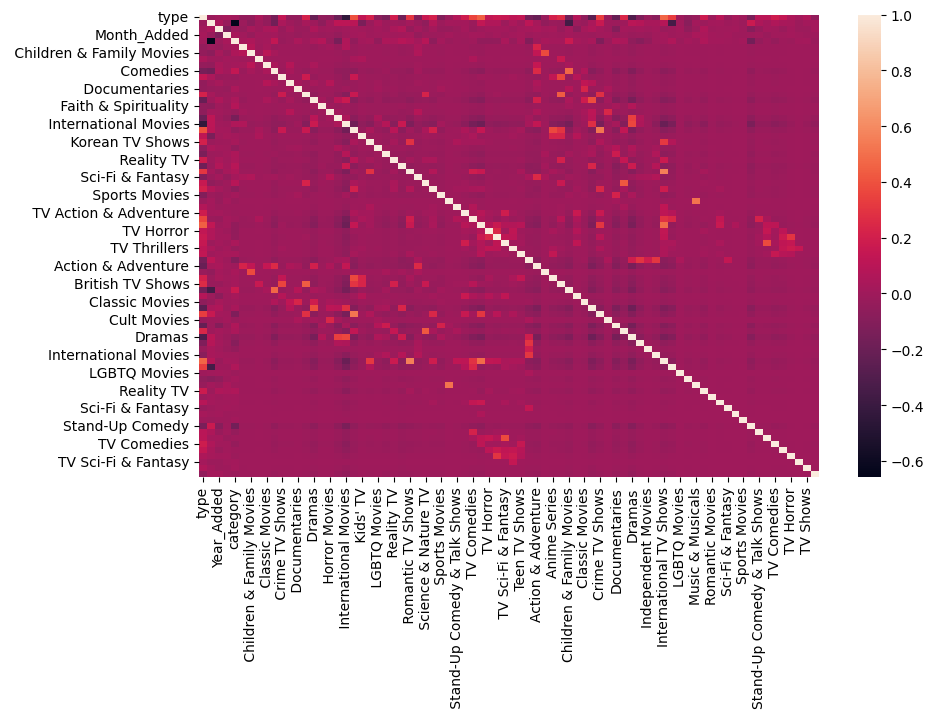

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix)
plt.show()